In [1]:
# 二、动手实现 logistic 回归

# 导入所需包和所需模块
import torch
import numpy as np
from torch.nn import BCELoss
import random
import matplotlib.pyplot as plt

In [2]:
def sigmoid(x):
    return 1 / (1 + torch.exp(-x))

In [ ]:
# 构造人工数据集
def create_data(num_examples,num_inputs):
    features = torch.tensor(np.random.rand(num_examples,num_inputs), dtype=torch.float)

    labels_x = torch.zeros(num_examples, dtype=torch.float)
    for i in range(num_inputs):
        labels_x += true_w[i] * features[:, i]
    labels = sigmoid(labels_x + true_b) # 生成标签

    noise = torch.tensor(np.random.normal(0, 0.01, size=labels.size()), dtype=torch.float) # 增加噪声
    labels += noise 
    
    num_0, num_1 = 0, 0
    for i in range(num_examples):
        if labels[i] < 0.5:
            labels[i] = 0
            num_0 += 1
        else:
            labels[i] = 1
            num_1 += 1
        labels = labels.view(-1,1)
    return features, labels, num_0, num_1


num_inputs = 4
true_w = [9.13, -7.091, 0.407, -1.134]
true_b = -1.379
train_examples, test_examples = 3500, 1500
train_data,train_labels, train_0, train_1 = create_data(train_examples,num_inputs)
test_data, test_labels, test_0, test_1 = create_data(test_examples,num_inputs)
print("共生成训练样本量: %d，其中 标签为'0' %d 样本， 标签为'1' %d 样本"%(train_examples,train_0,train_1))
print("共生成测试样本量: %d，其中 标签为'0' %d 样本， 标签为'1' %d 样本"%(test_examples,test_0,test_1))

# print(test_data[0:50])
# print(test_labels[0:50])

共生成训练样本量: 3500，其中 标签为'0' 2060 样本， 标签为'1' 1440 样本
共生成测试样本量: 1500，其中 标签为'0' 841 样本， 标签为'1' 659 样本


In [4]:
# 定义读取数据的函数
def data_iter(batch_size, features, labels):
    num_examples = len(features)
    indices = list(range(num_examples))
    random.shuffle(indices) # 样本的读取顺序是随机的
    for i in range(0, num_examples, batch_size):
        j = torch.LongTensor(indices[i: min(i + batch_size, num_examples)]) # 最后一次可能不足一个batch
        yield features.index_select(0, j), labels.index_select(0, j) # 返回数据及其标签
        # tensor.index_select(dim, index) 第dim个参数维度中的index位置挑选数据


In [ ]:
# logistics模型
w = torch.tensor(np.random.normal(0, 1, (num_inputs, 1)),dtype=torch.float32, requires_grad=True) 
b = torch.tensor([-1],dtype=torch.float32,requires_grad=True)
print(f'w: {w}\nb: {b}')

# init_w=w.clone().detach()
# init_b=b.clone().detach()

w: tensor([[-0.8101],
        [-1.0590],
        [ 0.4338],
        [ 0.4646]], requires_grad=True)
b: tensor([-1.], requires_grad=True)


In [6]:
# 定义logistic模型
def myLogistic(x, w, b):
    return 1/(1 + torch.exp(-1 * torch.mm(x,w) + b))
# 定义优化函数
def mySGD(params, lr, batch_size):
    for param in params:
        param.data -= lr*param.grad / batch_size

Epoch: 1    Loss: 0.77492  Acc: 0.447
Epoch: 10    Loss: 0.67964  Acc: 0.589
Epoch: 20    Loss: 0.63892  Acc: 0.644
Epoch: 30    Loss: 0.60632  Acc: 0.696
Epoch: 40    Loss: 0.57744  Acc: 0.733
Epoch: 50    Loss: 0.55164  Acc: 0.764
Epoch: 60    Loss: 0.52851  Acc: 0.785
Epoch: 70    Loss: 0.50771  Acc: 0.810
Epoch: 80    Loss: 0.48893  Acc: 0.829
Epoch: 90    Loss: 0.47190  Acc: 0.844
Epoch: 100    Loss: 0.45642  Acc: 0.857
Epoch: 110    Loss: 0.44230  Acc: 0.869
Epoch: 120    Loss: 0.42936  Acc: 0.881
Epoch: 130    Loss: 0.41748  Acc: 0.891
Epoch: 140    Loss: 0.40652  Acc: 0.898
Epoch: 150    Loss: 0.39639  Acc: 0.907
Epoch: 160    Loss: 0.38700  Acc: 0.915
Epoch: 170    Loss: 0.37827  Acc: 0.920
Epoch: 180    Loss: 0.37012  Acc: 0.924
Epoch: 190    Loss: 0.36251  Acc: 0.929
Epoch: 200    Loss: 0.35538  Acc: 0.933
Epoch: 210    Loss: 0.34869  Acc: 0.937
Epoch: 220    Loss: 0.34239  Acc: 0.941
Epoch: 230    Loss: 0.33645  Acc: 0.944
Epoch: 240    Loss: 0.33084  Acc: 0.946
Epoch: 250 

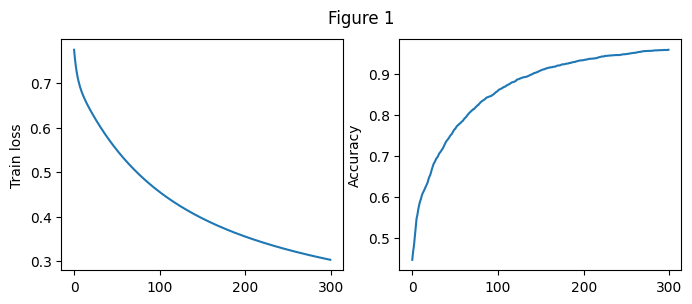

In [ ]:
# 训练
model = myLogistic  # logistics模型
criterion = BCELoss()   # 损失函数
lr = 0.35   # 学习率
batch_size = 64 # 批量大小
epochs = 300 # 训练轮数
train_all_loss = []
acc_all = []
max_acc = 0
for epoch in range(epochs):
    for data, labels in data_iter(batch_size,train_data,train_labels):

        pred = model(data, w, b)
        train_each_loss = criterion(pred, labels)
        train_each_loss.backward() # 反向传播
        mySGD([w,b], lr, batch_size) # 使用小批量随机梯度下降迭代模型参数
        # 梯度清零
        w.grad.data.zero_()
        b.grad.data.zero_()  
    
    # 计算在训练集上的损失和正确率
    labels_pred = model(train_data,w,b)
    train_l = criterion(labels_pred, train_labels.view(-1,1))
    train_all_loss.append(train_l.item())
    labels_pred = torch.tensor(np.where(labels_pred>0.5, 1, 0),dtype=torch.float32)

    acc = (labels_pred==train_labels).sum(0).item() / train_examples
    max_acc = max(acc,max_acc)
    acc_all.append(acc)
    if epoch==0 or (epoch+1) % 10 == 0:
        print('Epoch: %d    Loss: %.5f  Acc: %.3f'%(epoch+1,train_l.item(), acc))

# 损失与正确率曲线
plt.figure(figsize=(8,3))
plt.subplot(121)
plt.suptitle('Figure 1')
plt.plot(train_all_loss)
plt.ylabel('Train loss')
plt.subplot(122)
plt.ylabel('Accuracy')
plt.plot(acc_all)
plt.show()


In [8]:
# 计算测试集上的损失值和正确率
with torch.no_grad():
    labels_pred_test = model(test_data,w,b)
    test_l =  criterion(labels_pred_test, test_labels.view(-1,1))
    labels_pred_test = torch.tensor(np.where(labels_pred_test>0.5, 1, 0),dtype=torch.float32)
    acc_test = (labels_pred_test==test_labels).sum(0).item() / test_examples
    print('Test_loss: %.5f Test_acc: %.3f'%(test_l, acc_test))


Test_loss: 0.31021 Test_acc: 0.954


In [ ]:
print("理想参数: w: {}, b: {}".format(true_w, true_b))
# print("初始参数: w: {}, b: {}".format(init_w.reshape(1,-1).tolist()[0], init_b.item()))
print("训练得到的参数: w: {}, b: {}".format(w.reshape(1,-1).tolist()[0], b.item()))

理想参数: w: [9.13, -7.091, 0.407, -1.134], b: -1.379
训练得到的参数: w: [4.022867679595947, -3.6983163356781006, -0.10311718285083771, -0.672489583492279], b: 0.2369566708803177
